# 基于遗传编程 (GP) 的 FJSP 求解

遗传编程 (Genetic Programming, GP) 是遗传算法的扩展，不同之处在于 GP 的个体是**树结构**而非固定长度的染色体。

在本实现中，GP 树编码了一个**调度优先级函数**（Dispatching Rule），该函数根据工序的当前状态特征（加工时间、剩余工序数、机器负载等）计算优先级，
调度器每步选择优先级最高的可调度工序进行加工。

**机器选择**使用最早完工时间 (ECT) 规则，**工序排序**由 GP 树进化出的优先级函数决定。

In [10]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import copy

In [11]:
class Node:
    """GP tree node"""
    def __init__(self, ntype, value=None, left=None, right=None):
        self.ntype = ntype  # "op" or "term"
        self.value = value
        self.left = left
        self.right = right

FUNCS = [
    ("+", lambda a, b: a + b),
    ("-", lambda a, b: a - b),
    ("*", lambda a, b: a * b),
    ("pdiv", lambda a, b: a / b if abs(b) > 1e-6 else 1.0),
    ("max", lambda a, b: max(a, b)),
    ("min", lambda a, b: min(a, b)),
]
FUNC_NAMES = [f[0] for f in FUNCS]

TERMINALS = ["PT", "NOR", "ML", "JWT", "RAND"]

def random_terminal():
    return Node("term", value=random.choice(TERMINALS))

def random_op():
    return Node("op", value=random.choice(FUNC_NAMES))

def full_tree(depth):
    """Full method: all leaves at max depth"""
    if depth <= 0:
        return random_terminal()
    n = random_op()
    n.left = full_tree(depth - 1)
    n.right = full_tree(depth - 1)
    return n

def grow_tree(depth):
    """Grow method: leaves at varying depths"""
    if depth <= 0 or (depth > 0 and random.random() < 0.3):
        return random_terminal()
    n = random_op()
    n.left = grow_tree(depth - 1)
    n.right = grow_tree(depth - 1)
    return n

def create_tree(max_depth=4):
    """Ramped half-and-half initialization"""
    depth = random.randint(2, max_depth)
    if random.random() < 0.5:
        return full_tree(depth)
    else:
        return grow_tree(depth)

def tree_depth(node):
    if node is None or node.ntype == "term":
        return 0
    return 1 + max(tree_depth(node.left), tree_depth(node.right))

def tree_size(node):
    if node is None:
        return 0
    if node.ntype == "term":
        return 1
    return 1 + tree_size(node.left) + tree_size(node.right)

def tree_to_str(node):
    if node.ntype == "term":
        return node.value
    return f"({node.value} {tree_to_str(node.left)} {tree_to_str(node.right)})"

def eval_tree(node, features):
    """Evaluate GP tree given feature values"""
    if node.ntype == "term":
        if node.value == "RAND":
            return random.random()
        return features.get(node.value, 0.0)
    lv = eval_tree(node.left, features)
    rv = eval_tree(node.right, features)
    for name, func in FUNCS:
        if node.value == name:
            return func(lv, rv)
    return 0.0

In [12]:
def copy_tree(node):
    if node is None:
        return None
    if node.ntype == "term":
        return Node("term", value=node.value)
    return Node("op", value=node.value,
                left=copy_tree(node.left),
                right=copy_tree(node.right))

def get_random_subtree(node):
    """Get a random node (subtree root) from the tree"""
    nodes = []
    def collect(n):
        if n is None:
            return
        nodes.append(n)
        if n.ntype == "op":
            collect(n.left)
            collect(n.right)
    collect(node)
    return random.choice(nodes) if nodes else node

def createInd(J, P):
    """Create a GP tree individual for FJSP"""
    return create_tree(max_depth=4)

def createPop(J, P, popSize):
    return [createInd(J, P) for _ in range(popSize)]

In [13]:
def compute_features(job_idx, op_idx, job_end_time, machine_end_time,
                      machine_list, time_list, J, P, best_m_idx):
    """Compute features for GP priority evaluation"""
    p_time = time_list[best_m_idx]
    machine = machine_list[best_m_idx]
    start = max(job_end_time[job_idx], machine_end_time[machine])

    # Remaining operations
    nor = len(P[job_idx]) - op_idx

    # Machine load (current end time of the machine)
    ml = machine_end_time[machine]

    # Job waiting time
    jwt = start - job_end_time[job_idx]

    return {
        "PT": p_time,
        "NOR": float(nor),
        "ML": ml,
        "JWT": jwt,
        "RAND": 0.0  # evaluated at tree eval time
    }

def decode(tree, J, P):
    """
    Decode: use GP tree as priority rule for dispatching
    Machine selection uses Earliest Completion Time (ECT) rule.
    Operation sequencing uses GP tree priority.
    """
    n_jobs = len(J)
    n_ops = sum(len(job) for job in J)
    machine_num = max(max(m_list) for job in J for m_list in job) + 1

    job_step = [0] * n_jobs
    job_end_time = [0] * n_jobs
    machine_end_time = [0] * machine_num
    scheduled = set()
    schedule = []

    while len(scheduled) < n_ops:
        # Find ready operations: first unscheduled operation of each job
        ready = []
        for job_idx in range(n_jobs):
            op_idx = job_step[job_idx]
            if op_idx < len(J[job_idx]) and (job_idx, op_idx) not in scheduled:
                ready.append((job_idx, op_idx))

        if not ready:
            break

        # ECT rule for machine selection + GP priority for operation selection
        best_priority = -float("inf")
        best_op = None
        best_machine = None
        best_start = None
        best_end = None

        for job_idx, op_idx in ready:
            machine_list = J[job_idx][op_idx]
            time_list = P[job_idx][op_idx]

            # ECT: find machine with earliest completion time
            min_end = float("inf")
            best_m_idx = 0
            for m_idx in range(len(machine_list)):
                m = machine_list[m_idx]
                start = max(job_end_time[job_idx], machine_end_time[m])
                end = start + time_list[m_idx]
                if end < min_end:
                    min_end = end
                    best_m_idx = m_idx

            m = machine_list[best_m_idx]
            p_time = time_list[best_m_idx]
            start = max(job_end_time[job_idx], machine_end_time[m])
            end = start + p_time

            # Compute features
            features = compute_features(
                job_idx, op_idx, job_end_time, machine_end_time,
                machine_list, time_list, J, P, best_m_idx
            )

            # Evaluate GP tree
            priority = eval_tree(tree, features)

            if priority > best_priority:
                best_priority = priority
                best_op = (job_idx, op_idx)
                best_machine = m
                best_start = start
                best_end = end

        if best_op is None:
            break

        job_idx, op_idx = best_op
        schedule.append((job_idx, op_idx, best_machine, best_start, best_end))
        scheduled.add((job_idx, op_idx))
        job_step[job_idx] += 1
        job_end_time[job_idx] = best_end
        machine_end_time[best_machine] = best_end

    makespan = max(job_end_time)
    return schedule, makespan

In [14]:
def crossover(parent1, parent2, pc=0.8):
    """
    GP subtree crossover: swap random subtrees between parents
    """
    if random.random() > pc:
        return copy_tree(parent1), copy_tree(parent2)

    p1, p2 = copy_tree(parent1), copy_tree(parent2)

    # Find a random node in each tree
    # Collect all nodes with their parents
    def collect_with_parent(node, parent=None, parent_side=None):
        items = [(node, parent, parent_side)]
        if node.ntype == "op":
            items.extend(collect_with_parent(node.left, node, "left"))
            items.extend(collect_with_parent(node.right, node, "right"))
        return items

    items1 = collect_with_parent(p1)
    items2 = collect_with_parent(p2)

    node1, par1, side1 = random.choice(items1)
    node2, par2, side2 = random.choice(items2)

    # Swap subtrees
    copy2 = copy_tree(node2)
    if par1 is None:
        p1 = copy2  # root swap
    elif side1 == "left":
        par1.left = copy2
    else:
        par1.right = copy2

    copy1 = copy_tree(node1)
    if par2 is None:
        p2 = copy1
    elif side2 == "left":
        par2.left = copy1
    else:
        par2.right = copy1

    # Limit depth to prevent bloat
    max_depth = 6
    if tree_depth(p1) > max_depth:
        p1 = create_tree(max_depth=4)
    if tree_depth(p2) > max_depth:
        p2 = create_tree(max_depth=4)

    return p1, p2

def mutation(tree, pm=0.1):
    """GP mutation: replace a random subtree with a new random tree"""
    if random.random() > pm:
        return copy_tree(tree)

    mutant = copy_tree(tree)

    def mutate_node(node, parent=None, side=None):
        if node is None:
            return
        # 20% chance per node to replace, recursively
        if random.random() < 0.2 and node.ntype == "op":
            new_subtree = create_tree(max_depth=3)
            if parent is None:
                nonlocal mutant
                mutant = new_subtree
            elif side == "left":
                parent.left = new_subtree
            else:
                parent.right = new_subtree
            return
        if node.ntype == "op":
            mutate_node(node.left, node, "left")
            mutate_node(node.right, node, "right")

    mutate_node(mutant)

    if tree_depth(mutant) > 6:
        return create_tree(max_depth=4)
    return mutant

In [15]:
def choice(fitness, k=3, pool=None):
    """Tournament selection"""
    if pool is None:
        pool = len(fitness)
    n = len(fitness)
    result = []
    for _ in range(pool):
        indices = random.sample(range(n), k)
        best = indices[0]
        for idx in indices[1:]:
            if fitness[idx] < fitness[best]:
                best = idx
        result.append(best)
    return result

In [16]:
def draw_gantt(schedule, J, P, title="FJSP-GP Gantt Chart"):
    """Draw Gantt chart"""
    n_jobs = len(J)
    machine_num = max(max(m_list) for job in J for m_list in job) + 1
    colors = plt.cm.tab10(np.linspace(0, 1, n_jobs))
    fig, ax = plt.subplots(figsize=(14, 7))
    machine_ops = {i: [] for i in range(machine_num)}
    for job, op_idx, machine, start, end in schedule:
        machine_ops[machine].append((job, op_idx, start, end))
    for machine in range(machine_num):
        for job, op_idx, start, end in machine_ops[machine]:
            ax.barh(machine, end - start, left=start, height=0.6,
                    color=colors[job], edgecolor="black", linewidth=1)
            ax.text((start + end) / 2, machine, f"J{job}O{op_idx}",
                    ha="center", va="center", fontsize=9, fontweight="bold")
    ax.set_yticks(range(machine_num))
    ax.set_yticklabels([f"M{i}" for i in range(machine_num)])
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Machine", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(axis="x", alpha=0.3)
    patches = [mpatches.Patch(color=colors[i], label=f"Job {i}") for i in range(n_jobs)]
    ax.legend(handles=patches, loc="upper right")
    plt.tight_layout()
    plt.show()

def print_schedule(schedule):
    print("Job | Op | Machine | Start | End")
    print("---" * 8)
    for job, op_idx, machine, start, end in schedule:
        print(f" J{job} | {op_idx} |   M{machine}  |  {start:.0f}  | {end:.0f}")
    makespan = max(end for _, _, _, _, end in schedule)
    print(f"\nMakespan = {int(makespan)}")

In [17]:
def GP_FJSP(J, P, popSize=50, generations=100, pc=0.8, pm=0.1):
    """
    GP for FJSP: evolves dispatching rules as tree structures
    """
    n_jobs = len(J)
    n_ops = sum(len(job) for job in J)
    machine_num = max(max(m_list) for job in J for m_list in job) + 1
    print(f"FJSP实例: {n_jobs}个Job, {n_ops}道工序, {machine_num}台机器")
    print(f"GP参数: popSize={popSize}, gen={generations}, pc={pc}, pm={pm}")

    pop = createPop(J, P, popSize)
    best_makespan = float("inf")
    best_tree = None
    best_schedule = None
    best_history = []

    for gen in range(generations):
        fitness = []
        schedules = []
        for tree in pop:
            schedule, makespan = decode(tree, J, P)
            fitness.append(makespan)
            schedules.append(schedule)

        min_idx = int(np.argmin(fitness))
        gen_best = fitness[min_idx]
        best_history.append(gen_best)

        if gen_best < best_makespan:
            best_makespan = gen_best
            best_tree = copy_tree(pop[min_idx])
            best_schedule = schedules[min_idx]

        selected_idx = choice(fitness, k=3, pool=popSize)
        selected_trees = [copy_tree(pop[i]) for i in selected_idx]

        new_pop = []
        i = 0
        while i < popSize:
            if i + 1 < popSize and random.random() < pc:
                c1, c2 = crossover(selected_trees[i], selected_trees[i+1], pc=1.0)
                new_pop.append(c1)
                new_pop.append(c2)
                i += 2
            else:
                new_pop.append(copy_tree(selected_trees[i]))
                i += 1

        for i in range(len(new_pop)):
            new_pop[i] = mutation(new_pop[i], pm)

        pop = new_pop

        if (gen + 1) % 20 == 0 or gen == 0:
            print(f"Generation {gen+1:4d}: Best = {gen_best:3d}, Global Best = {best_makespan:3d}")

    print(f"\nFinal Results:")
    print(f"Best Makespan = {best_makespan}")
    print(f"Best rule: {tree_to_str(best_tree)}")
    print(f"Tree size: {tree_size(best_tree)}, depth: {tree_depth(best_tree)}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    ax1.plot(best_history, "b-", linewidth=1.5)
    ax1.set_xlabel("Generation")
    ax1.set_ylabel("Makespan")
    ax1.set_title("Convergence Curve")
    ax1.grid(alpha=0.3)

    draw_gantt(best_schedule, J, P, title=f"Best Schedule (Makespan={best_makespan})")
    print_schedule(best_schedule)

    return best_tree, best_makespan, best_schedule

Job数量: 4
总工序数: 12
机器数量: 5
已知最优 makespan = 11
FJSP实例: 4个Job, 12道工序, 5台机器
GP参数: popSize=50, gen=100, pc=0.8, pm=0.1
Generation    1: Best =  12, Global Best =  12
Generation   20: Best =  12, Global Best =  12
Generation   40: Best =  12, Global Best =  12
Generation   60: Best =  12, Global Best =  12
Generation   80: Best =  12, Global Best =  12
Generation  100: Best =  12, Global Best =  12

Final Results:
Best Makespan = 12
Best rule: NOR
Tree size: 1, depth: 0


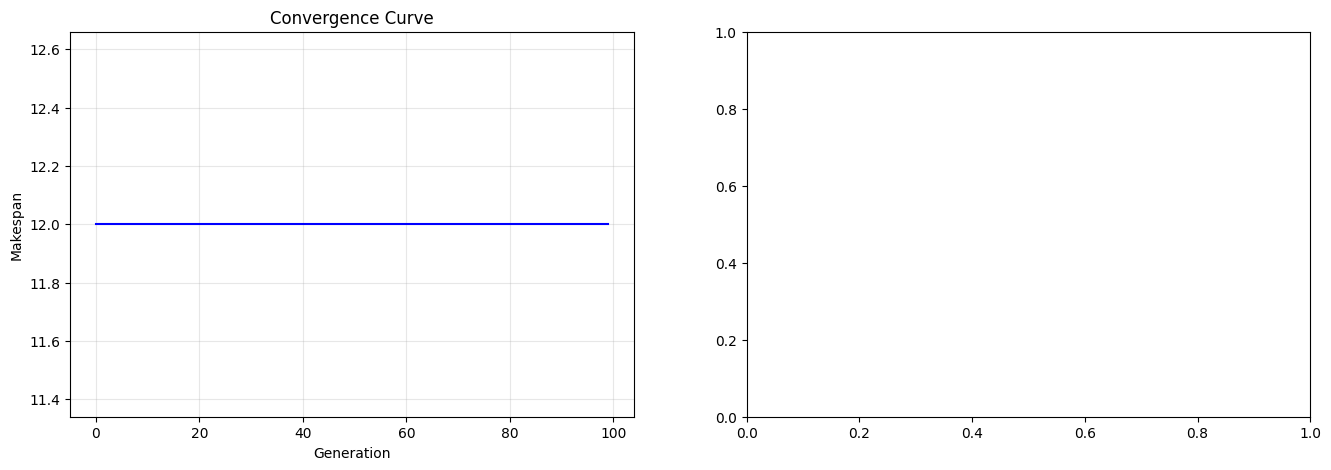

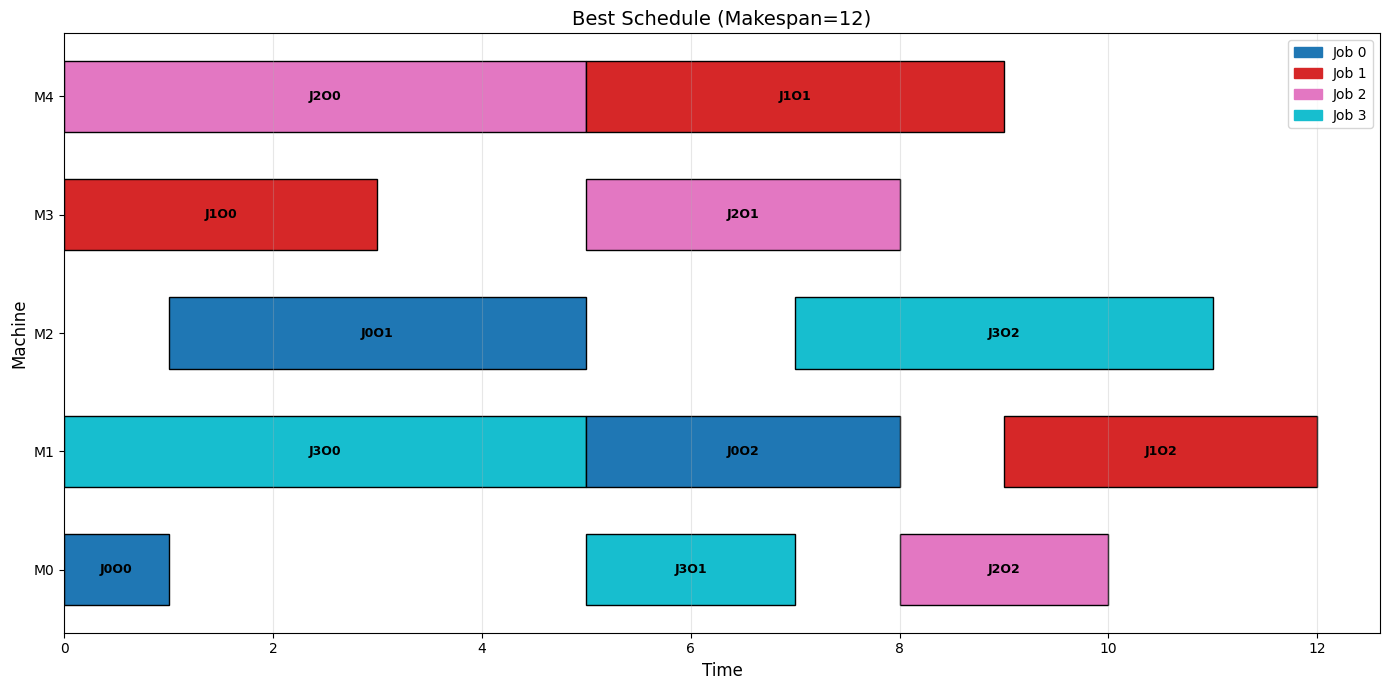

Job | Op | Machine | Start | End
------------------------
 J0 | 0 |   M0  |  0  | 1
 J1 | 0 |   M3  |  0  | 3
 J2 | 0 |   M4  |  0  | 5
 J3 | 0 |   M1  |  0  | 5
 J0 | 1 |   M2  |  1  | 5
 J1 | 1 |   M4  |  5  | 9
 J2 | 1 |   M3  |  5  | 8
 J3 | 1 |   M0  |  5  | 7
 J0 | 2 |   M1  |  5  | 8
 J1 | 2 |   M1  |  9  | 12
 J2 | 2 |   M0  |  8  | 10
 J3 | 2 |   M2  |  7  | 11

Makespan = 12


In [18]:
# Kacem 4x5 benchmark for FJSP-GP
J = [
    [[0,1,3,4], [1,2,3], [1,3,4]],
    [[0,2,3], [0,1,2,3,4], [0,1,2,4]],
    [[0,1,2,3,4], [1,2,3], [0,1,2,4]],
    [[0,1,2,3], [0,1,3,4], [0,1,2,4]]
]
P = [
    [[1,4,4,3], [6,4,3], [3,5,7]],
    [[5,5,3], [7,8,9,7,4], [6,3,8,5]],
    [[7,10,8,6,5], [4,5,3], [2,4,5,3]],
    [[5,5,6,4], [2,3,5,4], [4,3,4,6]]
]

n_jobs = len(J)
n_ops = sum(len(job) for job in J)
machine_num = max(max(m_list) for job in J for m_list in job) + 1
print(f"Job数量: {n_jobs}")
print(f"总工序数: {n_ops}")
print(f"机器数量: {machine_num}")
print(f"已知最优 makespan = 11")

# Run GP
best_tree, best_makespan, best_schedule = GP_FJSP(
    J, P,
    popSize=50,
    generations=100,
    pc=0.8,
    pm=0.1
)